# Part 1b: Dropout Regularization — TensorFlow & PyTorch

**Objective:** Show standard dropout as a regularization technique with A/B comparison.

**Key Idea:** During training, dropout randomly sets a fraction of neurons to zero. This prevents co-adaptation — neurons can't rely on specific other neurons being present, forcing the network to learn more robust features.

---

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
print(f"TF: {tf.__version__}, PyTorch: {torch.__version__}")

TF: 2.19.0, PyTorch: 2.10.0+cu128


## Data Preparation

In [2]:
# Load CIFAR-10
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()
X_train, X_test = X_train.astype("float32") / 255.0, X_test.astype("float32") / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
X_train_flat = X_train.reshape(len(X_train), -1)
X_test_flat = X_test.reshape(len(X_test), -1)
print(f"Train: {X_train_flat.shape}, Test: {X_test_flat.shape}")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
Train: (50000, 3072), Test: (10000, 3072)


## TensorFlow: Baseline vs Dropout
We compare a model with no dropout against models with 20%, 50% dropout rates.

In [3]:
# TF model builder with configurable dropout
def build_tf_dropout_model(dropout_rate=0.0, name="model"):
    model_layers = [layers.Input(shape=(3072,))]
    for units in [512, 256, 128]:
        model_layers.append(layers.Dense(units, activation='relu'))
        if dropout_rate > 0:
            model_layers.append(layers.Dropout(dropout_rate))
    model_layers.append(layers.Dense(10, activation='softmax'))
    model = keras.Sequential(model_layers, name=name)
    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

# Build and train models
results_tf = {}
for rate in [0.0, 0.2, 0.5]:
    name = f"dropout_{rate}"
    print(f"\n--- Training TF model with dropout={rate} ---")
    model = build_tf_dropout_model(rate, name)
    h = model.fit(X_train_flat, y_train, epochs=30, batch_size=256, validation_split=0.2, verbose=0)
    loss, acc = model.evaluate(X_test_flat, y_test, verbose=0)
    results_tf[f"Dropout {rate}"] = h
    print(f"Test Accuracy: {acc:.4f}")


--- Training TF model with dropout=0.0 ---
Test Accuracy: 0.5140

--- Training TF model with dropout=0.2 ---
Test Accuracy: 0.4811

--- Training TF model with dropout=0.5 ---
Test Accuracy: 0.2919


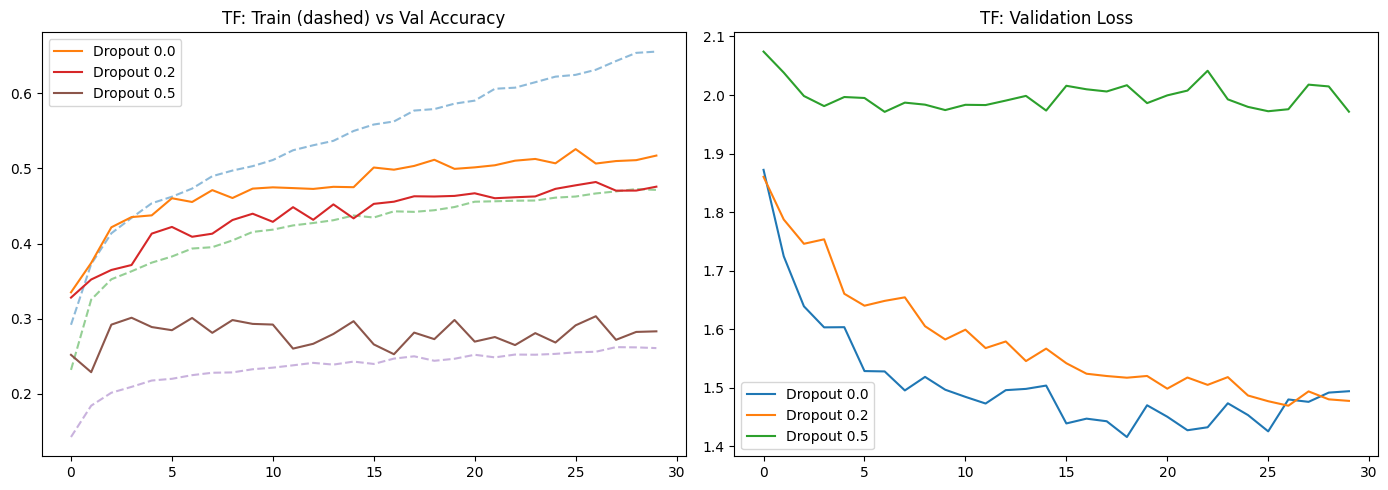

In [4]:
# Plot TF results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for name, h in results_tf.items():
    axes[0].plot(h.history['accuracy'], '--', alpha=0.5)
    axes[0].plot(h.history['val_accuracy'], label=name)
    axes[1].plot(h.history['val_loss'], label=name)
axes[0].set_title('TF: Train (dashed) vs Val Accuracy'); axes[0].legend()
axes[1].set_title('TF: Validation Loss'); axes[1].legend()
plt.tight_layout(); plt.show()

## PyTorch: Baseline vs Dropout

In [5]:
# PyTorch data
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
train_loader = DataLoader(TensorDataset(torch.FloatTensor(X_train_flat), torch.LongTensor(y_train)),
                          batch_size=256, shuffle=True)
test_loader = DataLoader(TensorDataset(torch.FloatTensor(X_test_flat), torch.LongTensor(y_test)),
                         batch_size=256)

class DropoutNet(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super().__init__()
        layers_list = []
        in_f = 3072
        for out_f in [512, 256, 128]:
            layers_list.extend([nn.Linear(in_f, out_f), nn.ReLU()])
            if dropout_rate > 0:
                layers_list.append(nn.Dropout(dropout_rate))
            in_f = out_f
        layers_list.append(nn.Linear(128, 10))
        self.net = nn.Sequential(*layers_list)

    def forward(self, x):
        return self.net(x)

def train_pt(model, epochs=30):
    model = model.to(device)
    opt = optim.Adam(model.parameters(), lr=1e-3)
    crit = nn.CrossEntropyLoss()
    hist = {'val_acc': []}
    for ep in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = crit(model(xb), yb); loss.backward(); opt.step()
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                correct += (model(xb).argmax(1) == yb).sum().item()
                total += yb.size(0)
        hist['val_acc'].append(correct / total)
    print(f"Final Val Acc: {hist['val_acc'][-1]:.4f}")
    return hist

results_pt = {}
for rate in [0.0, 0.2, 0.5]:
    print(f"\n--- PyTorch Dropout={rate} ---")
    results_pt[f"Dropout {rate}"] = train_pt(DropoutNet(rate))


--- PyTorch Dropout=0.0 ---
Final Val Acc: 0.5272

--- PyTorch Dropout=0.2 ---
Final Val Acc: 0.5133

--- PyTorch Dropout=0.5 ---
Final Val Acc: 0.4139


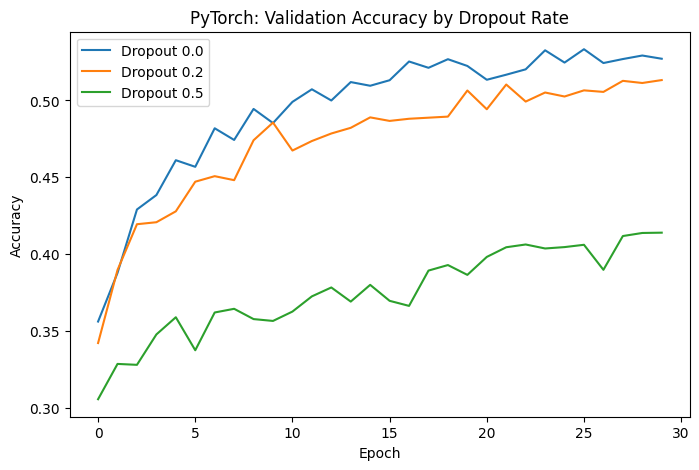

In [6]:
# Plot PyTorch results
plt.figure(figsize=(8, 5))
for name, h in results_pt.items():
    plt.plot(h['val_acc'], label=name)
plt.title('PyTorch: Validation Accuracy by Dropout Rate')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend(); plt.show()

## Key Takeaways
- **Dropout = 0.0** (no dropout): Model overfits — high train acc, lower val acc
- **Dropout = 0.2**: Mild regularization, good balance
- **Dropout = 0.5**: Strong regularization, slower to converge but better generalization
- Dropout is applied **only during training**; at inference, all neurons are active (with scaled outputs)
- Too much dropout can **underfit** — the model doesn't have enough capacity to learn